
Training PINN + HPM model...
Epoch 0: Train Loss = 0.094226, Val Loss = 0.187229
Epoch 50: Train Loss = 0.004502, Val Loss = 0.004205
Early stopping triggered.
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Train R2: 0.9965, Accuracy: 99.65%, Test R2: 0.9962, Accuracy: 99.62%

Training PINN + SPBA model...
Epoch 0: Train Loss = 0.133211, Val Loss = 0.180146
Epoch 50: Train Loss = 0.005700, Val Loss = 0.008016
Epoch 100: Train Loss = 0.005653, Val Loss = 0.010617
Epoch 150: Train Loss = 0.004835, Val Loss = 0.005402
Early stopping triggered.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Train R2: 0.9903, Accuracy: 99.03%, Test R2: 0.9899, Accuracy: 98.99%

Training PINN + CPSA model...
Epoch 0: Train Loss = 0.104762, Val Loss = 0.167920
Epoch 50: Train Loss = 0.005630, Val Loss = 0.004898
Early stopping triggered.
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Train R2: 0.9923, Accuracy: 99.23

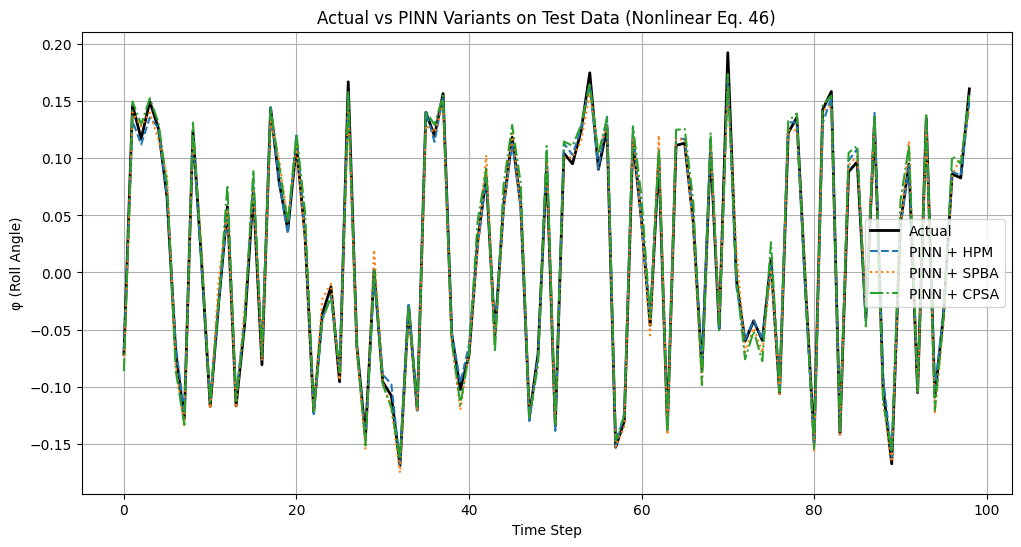

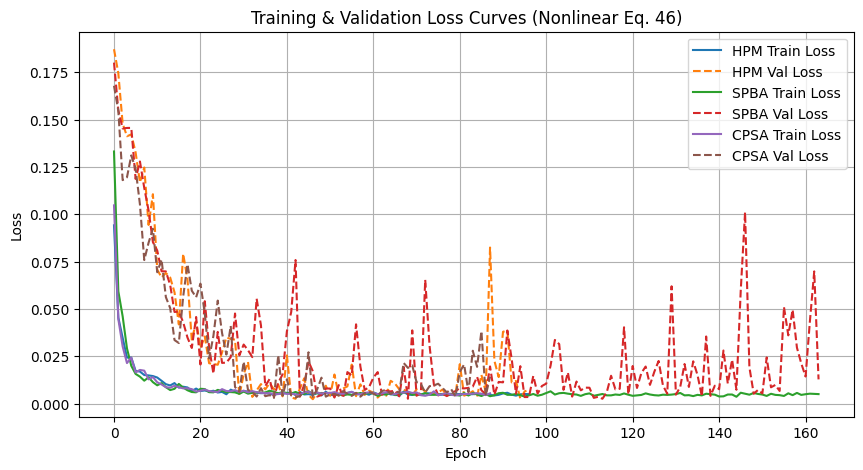

In [ ]:
# ============================================
# Imports
# ============================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, BatchNormalization
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# ============================================
# Reproducibility
# ============================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================
# Load Nonlinear Dataset (Eq. 46)
# ============================================
# Skip the header row when loading the data
df = pd.read_csv("roll_motion_table3_1000.csv", header=0)
df.columns = ["Time(s)", "phi", "phi_dot"]

X = df[['Time(s)', 'phi', 'phi_dot']].values
y = df['phi'].values.reshape(-1, 1)

# ============================================
# Normalization
# ============================================
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# ============================================
# Create Sequences
# ============================================
def create_sequences(X, y, lookback=16):
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback])
    return np.array(X_seq), np.array(y_seq)

lookback = 16
X_seq, y_seq = create_sequences(X_scaled, y_scaled, lookback)

# Split into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=0.2, random_state=SEED, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, shuffle=True)

# ============================================
# Build LSTM PINN Model
# ============================================
def build_model():
    input_layer = Input(shape=(lookback, X_train.shape[2]))
    x = LSTM(256, return_sequences=True)(input_layer)
    x = LSTM(128)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1)(x)
    model = Model(inputs=input_layer, outputs=output)
    return model

# ============================================
# Nonlinear Physics Residuals (Eq. 46)
# ============================================
@tf.function
def residual_hpm(x_batch, y_pred):
    phi_dot_seq = x_batch[:, -1:, 2:3]   # last φ̇
    phi_ddot_approx = phi_dot_seq - x_batch[:, -2:-1, 2:3]  # finite diff
    phi_t = y_pred
    phi_dot_t = phi_dot_seq
    return tf.squeeze(phi_ddot_approx + (0.01 + 0.1*phi_t**2)*phi_dot_t + phi_t - 1.75*phi_t**3, axis=-1)

@tf.function
def residual_spba(x_batch, y_pred):
    phi_dot_seq = x_batch[:, -1:, 2:3]
    phi_ddot_approx = 0.5*(phi_dot_seq - x_batch[:, -2:-1, 2:3])
    phi_t = y_pred
    phi_dot_t = phi_dot_seq
    return tf.squeeze(phi_ddot_approx + (0.01 + 0.1*phi_t**2)*phi_dot_t + phi_t - 1.75*phi_t**3, axis=-1)

@tf.function
def residual_cpsa(x_batch, y_pred):
    phi_dot_seq = x_batch[:, -3:, 2:3]
    phi_ddot_approx = tf.reduce_mean(phi_dot_seq[:, 1:, :] - phi_dot_seq[:, :-1, :], axis=1)
    phi_t = y_pred
    phi_dot_t = phi_dot_seq[:, -1:, :]
    return tf.squeeze(phi_ddot_approx + (0.01 + 0.1*phi_t**2)*phi_dot_t + phi_t - 1.75*phi_t**3, axis=-1)

# ============================================
# PINN Loss with Residual Variant
# ============================================
def pinn_loss(y_true, y_pred, x_batch, method='hpm', lambda_phys=0.05):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    if method == 'hpm':
        res = residual_hpm(x_batch, y_pred)
    elif method == 'spba':
        res = residual_spba(x_batch, y_pred)
    else:  # cpsa
        res = residual_cpsa(x_batch, y_pred)
    phys_loss = tf.reduce_mean(tf.square(res))
    return mse + lambda_phys * phys_loss

# ============================================
# Training Function
# ============================================
def train_model(model, X_train, y_train, X_val, y_val, method='hpm',
                epochs=600, batch_size=32, patience=50, lambda_phys=0.05):

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    best_val_loss = np.inf
    patience_counter = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        idx = np.random.permutation(len(X_train))
        X_train, y_train = X_train[idx], y_train[idx]
        batch_losses = []

        for i in range(0, len(X_train), batch_size):
            x_batch = tf.convert_to_tensor(X_train[i:i+batch_size], tf.float32)
            y_batch = tf.convert_to_tensor(y_train[i:i+batch_size], tf.float32)

            with tf.GradientTape() as tape:
                y_pred = model(x_batch, training=True)
                loss = pinn_loss(y_batch, y_pred, x_batch, method, lambda_phys)
            grads = tape.gradient(loss, model.trainable_variables)
            grads = [tf.clip_by_norm(g, 1.0) for g in grads]
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            batch_losses.append(loss.numpy())

        train_loss = np.mean(batch_losses)
        val_loss = pinn_loss(tf.convert_to_tensor(y_val, tf.float32),
                             model(tf.convert_to_tensor(X_val, tf.float32), training=False),
                             tf.convert_to_tensor(X_val, tf.float32),
                             method, lambda_phys).numpy()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_weights = model.get_weights()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                model.set_weights(best_weights)
                break

    return train_losses, val_losses

# ============================================
# Evaluation Function
# ============================================
def evaluate(model, X, y, scaler):
    y_pred = model.predict(X)
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_true_inv = scaler.inverse_transform(y)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    r2 = r2_score(y_true_inv, y_pred_inv)
    return y_true_inv, y_pred_inv, rmse, mae, r2, r2*100

# ============================================
# Train All PINN Variants
# ============================================
methods = ['hpm', 'spba', 'cpsa']
models = {}
results = {}
loss_histories = {}

for method in methods:
    print(f"\nTraining PINN + {method.upper()} model...")
    model = build_model()
    train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val, method, lambda_phys=0.05)
    y_train_true, y_train_pred, tr_rmse, tr_mae, tr_r2, tr_acc = evaluate(model, X_train, y_train, scaler_y)
    y_test_true, y_test_pred, ts_rmse, ts_mae, ts_r2, ts_acc = evaluate(model, X_test, y_test, scaler_y)
    print(f"Train R2: {tr_r2:.4f}, Accuracy: {tr_acc:.2f}%, Test R2: {ts_r2:.4f}, Accuracy: {ts_acc:.2f}%")

    models[method] = model
    results[method] = (y_test_true, y_test_pred)
    loss_histories[method] = (train_losses, val_losses)

# ============================================
# Plot predictions
# ============================================
plt.figure(figsize=(12, 6))
plt.plot(results['hpm'][0], label='Actual', color='black', linewidth=2)
plt.plot(results['hpm'][1], label='PINN + HPM', linestyle='dashed')
plt.plot(results['spba'][1], label='PINN + SPBA', linestyle='dotted')
plt.plot(results['cpsa'][1], label='PINN + CPSA', linestyle='dashdot')
plt.title('Actual vs PINN Variants on Test Data (Nonlinear Eq. 46)')
plt.xlabel('Time Step')
plt.ylabel('φ (Roll Angle)')
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# Plot loss curves
# ============================================
plt.figure(figsize=(10, 5))
for key, (train_loss, val_loss) in loss_histories.items():
    plt.plot(train_loss, label=f'{key.upper()} Train Loss')
    plt.plot(val_loss, label=f'{key.upper()} Val Loss', linestyle='dashed')
plt.title('Training & Validation Loss Curves (Nonlinear Eq. 46)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()